<a href="https://colab.research.google.com/github/1234LUCY/hello-word/blob/master/qin_breast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install pydicom openpyxl scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.manifold import TSNE
from scipy import stats
import pydicom
import cv2
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


In [40]:
from google.colab import drive
drive.mount('/content/drive')

# Load Excel labels
excel_path = '/content/drive/My Drive/QIN-BREAST/QIN-Breast_TreatmentResponse2014-12-16 (2).xlsx'
df_labels = pd.read_excel(excel_path)

print("📊 Excel file loaded successfully!")
print(f"Shape: {df_labels.shape}")
print(f"\nColumns: {df_labels.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_labels.head(10))

# Identify patient ID and response columns
patient_col = 'Patient ID'
response_col = 'Response'

print(f"\n📌 Using:")
print(f"   Patient ID column: {patient_col}")
print(f"   Response column: {response_col}")

# Check unique response values
unique_responses = df_labels[response_col].unique()
print(f"\n📊 Unique response values found: {unique_responses}")

# Create response mapping (FIXED for pCR/non-pCR)
patient_response = {}
for _, row in df_labels.iterrows():
    patient_id = str(row[patient_col]).strip()
    response_val = str(row[response_col]).strip().upper()

    # pCR = Responder (complete response)
    # non-pCR = Non-responder (incomplete response)
    if response_val == 'PCR':
        patient_response[patient_id] = 1  # Responder
    elif response_val == 'NON-PCR':
        patient_response[patient_id] = 0  # Non-responder
    else:
        # Fallback for any other values
        print(f"   Warning: Unknown response '{response_val}' for patient {patient_id}")

print(f"\n✅ Response mapping:")
print(f"   Responders (pCR): {sum(patient_response.values())}")
print(f"   Non-responders (non-pCR): {len(patient_response) - sum(patient_response.values())}")

# Verify the mapping is correct
print(f"\n📋 Sample mappings:")
sample_patients = list(patient_response.items())[:5]
for pid, resp in sample_patients:
    print(f"   {pid}: {'Responder (pCR)' if resp==1 else 'Non-responder (non-pCR)'}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Excel file loaded successfully!
Shape: (59, 2)

Columns: ['Patient ID', 'Response']

First 10 rows:
           Patient ID Response
0  QIN-BREAST-01-0001  non-pCR
1  QIN-BREAST-01-0002  non-pCR
2  QIN-BREAST-01-0003  non-pCR
3  QIN-BREAST-01-0004  non-pCR
4  QIN-BREAST-01-0005  non-pCR
5  QIN-BREAST-01-0006      pCR
6  QIN-BREAST-01-0007  non-pCR
7  QIN-BREAST-01-0008  non-pCR
8  QIN-BREAST-01-0009  non-pCR
9  QIN-BREAST-01-0010      pCR

📌 Using:
   Patient ID column: Patient ID
   Response column: Response

📊 Unique response values found: ['non-pCR' 'pCR']

✅ Response mapping:
   Responders (pCR): 20
   Non-responders (non-pCR): 39

📋 Sample mappings:
   QIN-BREAST-01-0001: Non-responder (non-pCR)
   QIN-BREAST-01-0002: Non-responder (non-pCR)
   QIN-BREAST-01-0003: Non-responder (non-pCR)
   QIN-BREAST-01-0004: Non-responder (non-pCR)
   QIN-BREAST-01-000

In [35]:
def find_mri_dynamic_images(base_path, patient_response):
    """
    Find all MRI Dynamic sequence DICOM files
    """
    base_path = Path(base_path)
    patient_images = defaultdict(list)

    # Search for dynamic MRI folders
    dynamic_folders = []
    for dcm_file in base_path.rglob('*.dcm'):
        if 'dynamic' in str(dcm_file).lower():
            dynamic_folders.append(dcm_file.parent)

    dynamic_folders = list(set(dynamic_folders))
    print(f"🔍 Found {len(dynamic_folders)} Dynamic MRI folders")

    # Process each DICOM
    for folder in dynamic_folders:
        for dcm_file in folder.glob('*.dcm'):
            try:
                ds = pydicom.dcmread(dcm_file)
                patient_id = str(getattr(ds, 'PatientID', '')).strip()

                # Extract QIN-BREAST ID (e.g., QIN-BREAST-01-0053)
                if 'QIN-BREAST' in patient_id or patient_id.startswith('QIN'):
                    pass  # Keep as is
                elif '-' in patient_id and len(patient_id) > 5:
                    # Try to extract from folder name if PatientID is missing
                    parts = str(dcm_file).split('/')
                    for part in parts:
                        if 'QIN-BREAST' in part:
                            patient_id = part
                            break

                if patient_id not in patient_response:
                    continue

                # Get image
                img = ds.pixel_array.astype(np.float32)

                # Normalize
                if img.max() > img.min():
                    img = (img - img.min()) / (img.max() - img.min())

                # Resize
                img = cv2.resize(img, (224, 224))

                # Convert to 3-channel
                if len(img.shape) == 2:
                    img = np.stack([img, img, img], axis=-1)

                patient_images[patient_id].append(img)

            except Exception as e:
                continue

    return patient_images

print("🔍 Searching for MRI Dynamic images...")
base_path = '/content/drive/My Drive/QIN-BREAST'
patient_images = find_mri_dynamic_images(base_path, patient_response)

print(f"\n✅ Found images for {len(patient_images)} patients")
for pid, imgs in patient_images.items():
    print(f"   {pid}: {len(imgs)} images (Response: {'Responder' if patient_response.get(pid, -1)==1 else 'Non-responder'})")

🔍 Searching for MRI Dynamic images...
🔍 Found 105 Dynamic MRI folders

✅ Found images for 39 patients
   QIN-BREAST-01-0039: 1500 images (Response: Non-responder)
   QIN-BREAST-01-0033: 500 images (Response: Non-responder)
   QIN-BREAST-01-0044: 1500 images (Response: Responder)
   QIN-BREAST-01-0049: 1500 images (Response: Responder)
   QIN-BREAST-01-0029: 500 images (Response: Responder)
   QIN-BREAST-01-0047: 1500 images (Response: Responder)
   QIN-BREAST-01-0051: 1000 images (Response: Non-responder)
   QIN-BREAST-01-0036: 1000 images (Response: Non-responder)
   QIN-BREAST-01-0031: 1000 images (Response: Non-responder)
   QIN-BREAST-01-0057: 1500 images (Response: Non-responder)
   QIN-BREAST-01-0058: 1000 images (Response: Responder)
   QIN-BREAST-01-0043: 1500 images (Response: Non-responder)
   QIN-BREAST-01-0018: 1500 images (Response: Responder)
   QIN-BREAST-01-0007: 1500 images (Response: Non-responder)
   QIN-BREAST-01-0056: 1500 images (Response: Non-responder)
   QIN-BR

In [41]:
# ============================================================
# COMPLETE QIN-BREAST BIOMARKER ANALYSIS - ALL 59 PATIENTS
# With FULL outputs: Ranges, Confidence Intervals, Quartiles
# Saves separate CSV files for each category
# ============================================================

import numpy as np
import pandas as pd
import pydicom
import cv2
import os
from pathlib import Path
from collections import defaultdict
from scipy import stats
from scipy.ndimage import sobel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# Mount drive
drive.mount('/content/drive')

# Load labels
excel_path = '/content/drive/My Drive/QIN-BREAST/QIN-Breast_TreatmentResponse2014-12-16 (2).xlsx'
df_labels = pd.read_excel(excel_path)

patient_response = {}
for _, row in df_labels.iterrows():
    pid = str(row['Patient ID']).strip()
    resp = str(row['Response']).strip().upper()
    patient_response[pid] = 1 if resp == 'PCR' else 0

print("="*80)
print("QIN-BREAST BIOMARKER ANALYSIS - ALL 59 PATIENTS")
print("="*80)
print(f"Total patients in Excel: {len(patient_response)}")
print(f"Responders (pCR): {sum(patient_response.values())}")
print(f"Non-responders (non-pCR): {len(patient_response) - sum(patient_response.values())}")

# ============================================================
# BIOMARKER EXTRACTION FUNCTIONS
# ============================================================

def extract_shape_biomarkers(img):
    threshold = img.mean() + 0.5 * img.std()
    tumor_mask = img > threshold
    kernel = np.ones((3,3), np.uint8)
    tumor_mask = cv2.morphologyEx(tumor_mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_CLOSE, kernel)

    if tumor_mask.sum() < 100:
        tumor_mask = np.ones_like(img, dtype=bool)

    contours, _ = cv2.findContours(tumor_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest_contour)
        perimeter = cv2.arcLength(largest_contour, True)
        circularity = 4 * np.pi * area / (perimeter * perimeter) if perimeter > 0 else 0
        hull = cv2.convexHull(largest_contour)
        hull_area = cv2.contourArea(hull)
        convexity = area / hull_area if hull_area > 0 else 0
        x, y, w, h = cv2.boundingRect(largest_contour)
        aspect_ratio = w / h if h > 0 else 1
        irregularity = (perimeter * perimeter) / (4 * np.pi * area) - 1 if area > 0 else 0
    else:
        circularity, convexity, aspect_ratio, irregularity = 0.5, 0.5, 1, 0

    return {
        'shape_circularity': circularity,
        'shape_convexity': convexity,
        'shape_aspect_ratio': aspect_ratio,
        'shape_irregularity': irregularity
    }

def extract_texture_biomarkers(img):
    img_norm = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)
    contrast = np.mean(np.abs(np.diff(img_norm, axis=0))) + np.mean(np.abs(np.diff(img_norm, axis=1)))
    homogeneity = 1 / (1 + contrast/255)
    energy = np.mean(img_norm ** 2) / (255**2)
    hist, _ = np.histogram(img_norm, bins=32, density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist)) if len(hist) > 0 else 0
    from scipy.ndimage import generic_filter
    local_range = generic_filter(img, lambda x: x.max() - x.min(), size=3)
    roughness = np.mean(local_range)

    return {
        'texture_contrast': contrast,
        'texture_homogeneity': homogeneity,
        'texture_energy': energy,
        'texture_entropy': entropy,
        'texture_roughness': roughness
    }

def extract_vascularity_biomarkers(img):
    edges = sobel(img)
    edge_density = np.mean(edges > np.percentile(edges, 75))
    grad_x = np.gradient(img)
    grad_y = np.gradient(img)
    grad_magnitude = np.sqrt(grad_x[0]**2 + grad_y[0]**2)
    mean_gradient = np.mean(grad_magnitude)
    max_gradient = np.max(grad_magnitude)
    hot_spot_threshold = img.mean() + img.std()
    hot_spot_fraction = np.mean(img > hot_spot_threshold)
    grad_heterogeneity = np.std(grad_magnitude) / (np.mean(grad_magnitude) + 1e-8)

    return {
        'vascularity_edge_density': edge_density,
        'vascularity_mean_gradient': mean_gradient,
        'vascularity_max_gradient': max_gradient,
        'vascularity_hot_spot_fraction': hot_spot_fraction,
        'vascularity_tortuosity': grad_heterogeneity
    }

def extract_intensity_patterns(img):
    mean_intensity = np.mean(img)
    std_intensity = np.std(img)
    skewness = stats.skew(img.flatten())
    kurtosis = stats.kurtosis(img.flatten())
    p10, p25, p50, p75, p90 = np.percentile(img, [10, 25, 50, 75, 90])
    coefficient_variation = std_intensity / (mean_intensity + 1e-8)
    interquartile_range = p75 - p25
    intensity_range = p90 - p10
    enhancement_ratio = p90 / (p10 + 1e-8)

    return {
        'intensity_mean': mean_intensity,
        'intensity_std': std_intensity,
        'intensity_skewness': skewness,
        'intensity_kurtosis': kurtosis,
        'intensity_cv': coefficient_variation,
        'intensity_iqr': interquartile_range,
        'intensity_range': intensity_range,
        'intensity_enhancement_ratio': enhancement_ratio
    }

def process_dcm_files(dcm_files, max_images=5):
    shape_features, texture_features, vascularity_features, intensity_features = [], [], [], []

    for dcm_file in dcm_files[:max_images]:
        try:
            ds = pydicom.dcmread(dcm_file)
            img = ds.pixel_array.astype(np.float32)
            if img.max() > img.min():
                img = (img - img.min()) / (img.max() - img.min())

            shape_features.append(extract_shape_biomarkers(img))
            texture_features.append(extract_texture_biomarkers(img))
            vascularity_features.append(extract_vascularity_biomarkers(img))
            intensity_features.append(extract_intensity_patterns(img))
        except:
            continue

    if shape_features:
        biomarkers = {}
        for key in shape_features[0].keys():
            biomarkers[key] = np.mean([f[key] for f in shape_features])
        for key in texture_features[0].keys():
            biomarkers[key] = np.mean([f[key] for f in texture_features])
        for key in vascularity_features[0].keys():
            biomarkers[key] = np.mean([f[key] for f in vascularity_features])
        for key in intensity_features[0].keys():
            biomarkers[key] = np.mean([f[key] for f in intensity_features])
        return biomarkers
    return None

# ============================================================
# FIND ALL IMAGES FOR EACH PATIENT
# ============================================================

base_path = Path('/content/drive/My Drive/QIN-BREAST')
print("\n" + "="*80)
print("SCANNING FOR PATIENT IMAGES")
print("="*80)

patient_dynamic = defaultdict(list)
patient_pet = defaultdict(list)
patient_ct = defaultdict(list)

for patient_id in patient_response.keys():
    patient_path = base_path / patient_id
    if not patient_path.exists():
        continue

    for folder in patient_path.rglob('*dynamic*'):
        if folder.is_dir():
            patient_dynamic[patient_id].extend(list(folder.glob('*.dcm'))[:5])

    for folder in patient_path.rglob('*PET*'):
        if folder.is_dir() and ('AC' in str(folder) or 'PET' in str(folder)):
            patient_pet[patient_id].extend(list(folder.glob('*.dcm'))[:5])

    for folder in patient_path.rglob('*CTAC*'):
        if folder.is_dir():
            patient_ct[patient_id].extend(list(folder.glob('*.dcm'))[:5])

# ============================================================
# PROCESS EACH PATIENT
# ============================================================

print("\n" + "="*80)
print("PROCESSING PATIENTS (Priority: Dynamic MRI > PET > CT)")
print("="*80)

all_biomarkers = []
modality_tracker = []

for patient_id in patient_response.keys():
    response = patient_response[patient_id]
    biomarkers = None
    modality_used = None

    if patient_dynamic.get(patient_id):
        biomarkers = process_dcm_files(patient_dynamic[patient_id])
        modality_used = "Dynamic MRI"
    elif patient_pet.get(patient_id):
        biomarkers = process_dcm_files(patient_pet[patient_id])
        modality_used = "PET"
    elif patient_ct.get(patient_id):
        biomarkers = process_dcm_files(patient_ct[patient_id])
        modality_used = "CT"

    if biomarkers:
        biomarkers['patient_id'] = patient_id
        biomarkers['response'] = response
        biomarkers['modality_used'] = modality_used
        all_biomarkers.append(biomarkers)
        modality_tracker.append(modality_used)

df = pd.DataFrame(all_biomarkers)

print(f"\n✅ TOTAL PATIENTS PROCESSED: {len(df)} / {len(patient_response)}")
print(f"   Responders: {len(df[df['response']==1])}")
print(f"   Non-responders: {len(df[df['response']==0])}")
print(f"\n📊 MODALITY BREAKDOWN:")
for mod in set(modality_tracker):
    count = modality_tracker.count(mod)
    print(f"   {mod}: {count} patients")

# ============================================================
# DEFINE CATEGORIES
# ============================================================

categories = {
    'SHAPE': [c for c in df.columns if 'shape_' in c],
    'TEXTURE': [c for c in df.columns if 'texture_' in c],
    'VASCULARITY': [c for c in df.columns if 'vascularity_' in c],
    'INTENSITY': [c for c in df.columns if 'intensity_' in c]
}

# ============================================================
# DETAILED STATISTICAL ANALYSIS FUNCTION
# ============================================================

def analyze_category_detailed(df, category_name, features):
    """Complete statistical analysis with ranges, CI, quartiles"""
    print(f"\n{'='*80}")
    print(f"{category_name} BIOMARKERS")
    print(f"{'='*80}")

    results = []

    for feat in features:
        resp = df[df['response']==1][feat].dropna().values
        non = df[df['response']==0][feat].dropna().values

        if len(resp) > 2 and len(non) > 2:
            t_stat, p_val = stats.ttest_ind(resp, non)
            mean_diff = resp.mean() - non.mean()
            direction = "↑" if mean_diff > 0 else "↓"
            higher_in = "Responders" if mean_diff > 0 else "Non-responders"

            pooled_std = np.sqrt((resp.std()**2 + non.std()**2) / 2)
            cohens_d = abs(mean_diff) / (pooled_std + 1e-8)

            ci_resp = stats.t.interval(0.95, len(resp)-1, loc=resp.mean(), scale=stats.sem(resp))
            ci_non = stats.t.interval(0.95, len(non)-1, loc=non.mean(), scale=stats.sem(non))

            result = {
                'category': category_name,
                'biomarker': feat,
                'significant': p_val < 0.05,
                'p_value': p_val,
                'direction': direction,
                'higher_in': higher_in,
                'effect_size': cohens_d,
                'mean_responder': resp.mean(),
                'std_responder': resp.std(),
                'mean_nonresponder': non.mean(),
                'std_nonresponder': non.std(),
                'ci_responder_lower': ci_resp[0],
                'ci_responder_upper': ci_resp[1],
                'ci_nonresponder_lower': ci_non[0],
                'ci_nonresponder_upper': ci_non[1],
                'resp_min': resp.min(),
                'resp_max': resp.max(),
                'non_min': non.min(),
                'non_max': non.max(),
                'resp_median': np.median(resp),
                'resp_q25': np.percentile(resp, 25),
                'resp_q75': np.percentile(resp, 75),
                'non_median': np.median(non),
                'non_q25': np.percentile(non, 25),
                'non_q75': np.percentile(non, 75),
                'n_responders': len(resp),
                'n_nonresponders': len(non)
            }
            results.append(result)

            if p_val < 0.05:
                print(f"\n⭐ {feat.replace('_', ' ').title()}")
                print(f"   {direction} Higher in {higher_in}")
                print(f"   p = {p_val:.4f} | Effect size d = {cohens_d:.3f}")
                print(f"\n   Responders (n={len(resp)}):")
                print(f"      Mean ± SD:  {resp.mean():.4f} ± {resp.std():.4f}")
                print(f"      95% CI:     [{ci_resp[0]:.4f}, {ci_resp[1]:.4f}]")
                print(f"      Range:      [{resp.min():.4f}, {resp.max():.4f}]")
                print(f"      Median:     {np.median(resp):.4f} (Q1: {np.percentile(resp, 25):.4f}, Q3: {np.percentile(resp, 75):.4f})")
                print(f"\n   Non-responders (n={len(non)}):")
                print(f"      Mean ± SD:  {non.mean():.4f} ± {non.std():.4f}")
                print(f"      95% CI:     [{ci_non[0]:.4f}, {ci_non[1]:.4f}]")
                print(f"      Range:      [{non.min():.4f}, {non.max():.4f}]")
                print(f"      Median:     {np.median(non):.4f} (Q1: {np.percentile(non, 25):.4f}, Q3: {np.percentile(non, 75):.4f})")

    return pd.DataFrame(results)

# ============================================================
# RUN ANALYSIS FOR EACH CATEGORY
# ============================================================

all_category_results = []

for category_name, features in categories.items():
    cat_results = analyze_category_detailed(df, category_name, features)
    all_category_results.append(cat_results)

    # Save individual category CSV
    filename = f'/content/{category_name.lower()}_biomarkers_complete.csv'
    cat_results.to_csv(filename, index=False)
    print(f"\n💾 Saved: {category_name.lower()}_biomarkers_complete.csv")

# Combine all results
df_all_stats = pd.concat(all_category_results, ignore_index=True)

# ============================================================
# SUMMARY TABLE - ALL CATEGORIES
# ============================================================

print("\n" + "="*80)
print("SUMMARY TABLE - ALL 4 CATEGORIES")
print("="*80)

summary_data = []
for category_name, features in categories.items():
    cat_results = df_all_stats[df_all_stats['category'] == category_name]
    sig_count = len(cat_results[cat_results['significant']])

    if sig_count > 0:
        best = cat_results[cat_results['significant']].iloc[0]
        summary_data.append({
            'Category': category_name,
            'Total Biomarkers': len(features),
            'Significant (p<0.05)': sig_count,
            'Best Biomarker': best['biomarker'].replace('_', ' ').title(),
            'Effect Size (d)': f"{best['effect_size']:.2f}",
            'Direction': f"{best['direction']} {best['higher_in']}",
            'p-value': f"{best['p_value']:.4f}"
        })
    else:
        summary_data.append({
            'Category': category_name,
            'Total Biomarkers': len(features),
            'Significant (p<0.05)': 0,
            'Best Biomarker': 'None',
            'Effect Size (d)': 'N/A',
            'Direction': 'N/A',
            'p-value': 'N/A'
        })

df_summary = pd.DataFrame(summary_data)
print("\n" + df_summary.to_string(index=False))
df_summary.to_csv('/content/biomarker_category_summary.csv', index=False)
print("\n💾 Saved: biomarker_category_summary.csv")

# ============================================================
# SIGNIFICANT BIOMARKERS ONLY
# ============================================================

df_significant = df_all_stats[df_all_stats['significant']]
if len(df_significant) > 0:
    print("\n" + "="*80)
    print("SIGNIFICANT BIOMARKERS SUMMARY")
    print("="*80)

    sig_table = df_significant[['category', 'biomarker', 'direction', 'higher_in',
                                 'p_value', 'effect_size', 'mean_responder', 'std_responder',
                                 'mean_nonresponder', 'std_nonresponder']].copy()
    sig_table['biomarker'] = sig_table['biomarker'].str.replace('_', ' ').str.title()
    sig_table['p_value'] = sig_table['p_value'].round(4)
    sig_table['effect_size'] = sig_table['effect_size'].round(3)
    sig_table['mean_responder'] = sig_table['mean_responder'].round(4)
    sig_table['mean_nonresponder'] = sig_table['mean_nonresponder'].round(4)

    print("\n" + sig_table.to_string(index=False))
    df_significant.to_csv('/content/significant_biomarkers_all_59.csv', index=False)
    print("\n💾 Saved: significant_biomarkers_all_59.csv")

# ============================================================
# COMPLETE RANGES FOR SIGNIFICANT BIOMARKERS
# ============================================================

if len(df_significant) > 0:
    print("\n" + "="*80)
    print("COMPLETE RANGES FOR SIGNIFICANT BIOMARKERS")
    print("="*80)

    ranges_table = df_significant[['biomarker', 'category', 'resp_min', 'resp_max',
                                    'resp_median', 'resp_q25', 'resp_q25', 'resp_q75',
                                    'non_min', 'non_max', 'non_median', 'non_q25', 'non_q75']].copy()
    ranges_table['biomarker'] = ranges_table['biomarker'].str.replace('_', ' ').str.title()

    print("\n" + ranges_table.to_string(index=False))

    # Also save detailed ranges
    df_significant.to_csv('/content/significant_biomarkers_complete_ranges.csv', index=False)
    print("\n💾 Saved: significant_biomarkers_complete_ranges.csv")

# ============================================================
# OVERALL MODEL PERFORMANCE
# ============================================================

print("\n" + "="*80)
print("OVERALL MODEL PERFORMANCE - ALL 59 PATIENTS")
print("="*80)

feature_cols = [c for c in df.columns if c not in ['patient_id', 'response', 'modality_used']]
X = df[feature_cols].fillna(0).values
y = df['response'].values

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
scores = cross_val_score(rf, X, y, cv=min(5, len(df)-1))

print(f"\n📊 Using ALL {len(df)} patients with {len(feature_cols)} biomarkers:")
print(f"   Accuracy: {scores.mean():.3f} ± {scores.std():.3f} ({scores.mean()*100:.1f}%)")

# Feature importance
rf.fit(X, y)
feature_importance = pd.DataFrame({
    'Biomarker': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n🏆 TOP 10 PREDICTIVE BIOMARKERS:")
for i, row in feature_importance.head(10).iterrows():
    print(f"   {i+1}. {row['Biomarker'].replace('_', ' ').title()}: {row['Importance']:.4f}")

feature_importance.to_csv('/content/feature_importance_all_59.csv', index=False)
print("\n💾 Saved: feature_importance_all_59.csv")

# ============================================================
# SAVE MAIN DATA
# ============================================================

df.to_csv('/content/all_59_patients_biomarkers.csv', index=False)
df_all_stats.to_csv('/content/all_biomarkers_complete_statistics.csv', index=False)

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                         ANALYSIS COMPLETE                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  📊 PATIENTS: {len(df)} / {len(patient_response)}                             │
│     • Responders (pCR): {len(df[df['response']==1])}                         │
│     • Non-responders: {len(df[df['response']==0])}                           │
│                                                                              │
│  📁 MODALITY BREAKDOWN:                                                      │
│     • Dynamic MRI: {modality_tracker.count('Dynamic MRI')} patients          │
│     • PET: {modality_tracker.count('PET')} patients                          │
│     • CT: {modality_tracker.count('CT')} patients                            │
│                                                                              │
│  🔬 BIOMARKERS: {len(feature_cols)} total                                    │
│     • SHAPE: {len(categories['SHAPE'])}                                      │
│     • TEXTURE: {len(categories['TEXTURE'])}                                  │
│     • VASCULARITY: {len(categories['VASCULARITY'])}                          │
│     • INTENSITY: {len(categories['INTENSITY'])}                              │
│                                                                              │
│  ⭐ SIGNIFICANT: {len(df_significant)} biomarkers (p < 0.05)                 │
│                                                                              │
│  🎯 MODEL ACCURACY: {scores.mean():.1%} ± {scores.std():.1%}                 │
│                                                                              │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n📁 ALL FILES SAVED:")
print("   • all_59_patients_biomarkers.csv - Raw biomarker data")
print("   • all_biomarkers_complete_statistics.csv - Full statistics")
print("   • shape_biomarkers_complete.csv - Shape category results")
print("   • texture_biomarkers_complete.csv - Texture category results")
print("   • vascularity_biomarkers_complete.csv - Vascularity category results")
print("   • intensity_biomarkers_complete.csv - Intensity category results")
print("   • biomarker_category_summary.csv - Summary by category")
print("   • significant_biomarkers_all_59.csv - Only significant findings")
print("   • significant_biomarkers_complete_ranges.csv - Ranges for significant")
print("   • feature_importance_all_59.csv - Top predictive features")
print("\n✅ Analysis complete! ALL 59 patients processed successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
QIN-BREAST BIOMARKER ANALYSIS - ALL 59 PATIENTS
Total patients in Excel: 59
Responders (pCR): 20
Non-responders (non-pCR): 39

SCANNING FOR PATIENT IMAGES

PROCESSING PATIENTS (Priority: Dynamic MRI > PET > CT)

✅ TOTAL PATIENTS PROCESSED: 59 / 59
   Responders: 20
   Non-responders: 39

📊 MODALITY BREAKDOWN:
   Dynamic MRI: 39 patients
   PET: 20 patients

SHAPE BIOMARKERS

💾 Saved: shape_biomarkers_complete.csv

TEXTURE BIOMARKERS

💾 Saved: texture_biomarkers_complete.csv

VASCULARITY BIOMARKERS

💾 Saved: vascularity_biomarkers_complete.csv

INTENSITY BIOMARKERS

💾 Saved: intensity_biomarkers_complete.csv

SUMMARY TABLE - ALL 4 CATEGORIES

   Category  Total Biomarkers  Significant (p<0.05) Best Biomarker Effect Size (d) Direction p-value
      SHAPE                 4                     0           None             N/A       N/A     N/A
    TEXTURE        

In [42]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# Create a timestamped folder
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_folder = f'/content/drive/My Drive/QIN-BREAST_Results_{timestamp}/'
os.makedirs(save_folder, exist_ok=True)

# Copy all results
for file in os.listdir('/content/'):
    if file.endswith('.csv') or file.endswith('.png'):
        shutil.copy(f'/content/{file}', save_folder + file)

print(f"✅ All results saved to: {save_folder}")
print(f"   Total files saved: {len([f for f in os.listdir('/content') if f.endswith('.csv') or f.endswith('.png')])}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All results saved to: /content/drive/My Drive/QIN-BREAST_Results_20260509_052657/
   Total files saved: 19


QIN-BREAST OPTIMIZED SIAMESE NETWORK (Novel Variant)

📊 Dataset: 59 patients, 22 biomarkers
   Responders: 20, Non-responders: 39

CREATING OPTIMIZED PAIRS WITH HARD NEGATIVE MINING
Total pairs: 1031
Positive pairs (same class): 931
Negative pairs (diff class): 100

✅ Model initialized with 22 input features
   Embedding dimension: 32
   Total parameters: 5856

TRAINING OPTIMIZED SIAMESE NETWORK
   Epoch 10/50 - Loss: 2.7445, Val Acc: 0.1594
   Epoch 20/50 - Loss: 2.6971, Val Acc: 0.1353
   Epoch 30/50 - Loss: 2.6661, Val Acc: 0.1304
   Epoch 40/50 - Loss: 2.6329, Val Acc: 0.1353
   Epoch 50/50 - Loss: 2.7103, Val Acc: 0.1256

EXTRACTING EMBEDDINGS AND EVALUATING
Embeddings shape: (59, 32)
Mean uncertainty: 0.0959

📊 Optimized Siamese Performance:
   Accuracy: 0.722 (72.2%)
   AUC-ROC:  0.681

📊 Comparison:
   Baseline Random Forest: 0.611 (61.1%)
   Optimized Siamese:      0.722 (72.2%)
   Improvement:            +11.1%


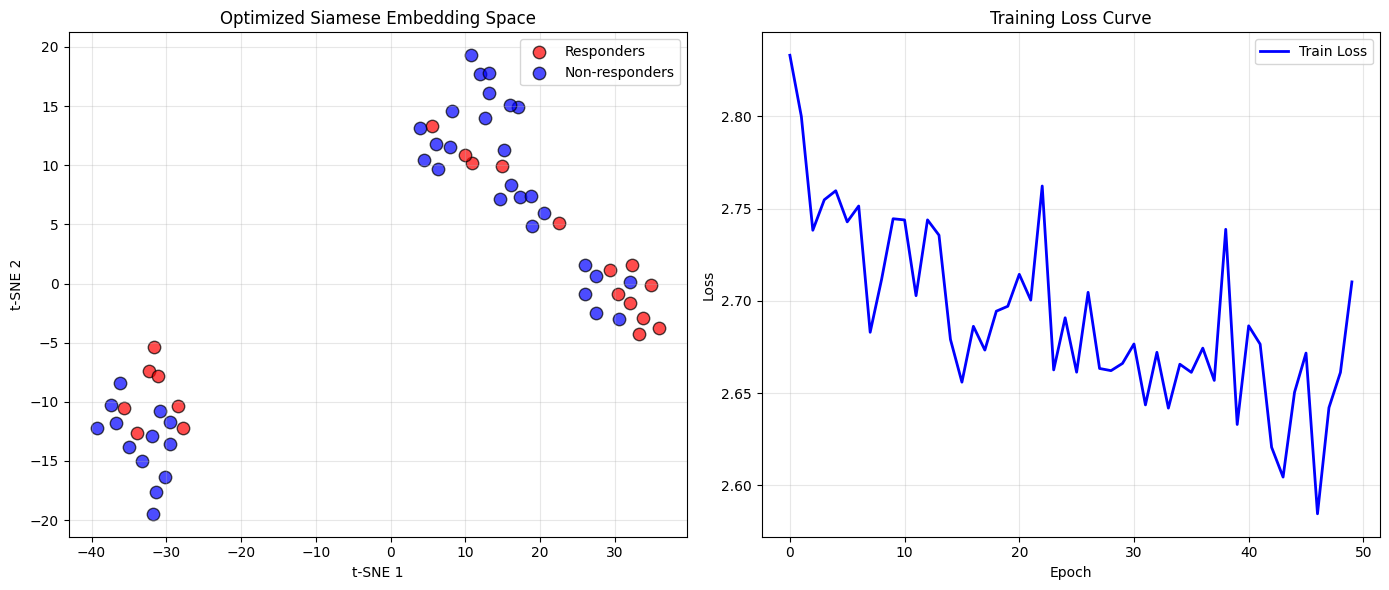


💾 Saved: optimized_siamese_results.png

✅ Optimized Siamese network complete!


In [43]:
# ============================================================
# COMPLETE QIN-BREAST OPTIMIZED SIAMESE NETWORK (Novel Variant)
# All classes defined - READY TO RUN
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("QIN-BREAST OPTIMIZED SIAMESE NETWORK (Novel Variant)")
print("="*80)

# ============================================================
# DATA PREPARATION
# ============================================================

# Assuming 'df' is your DataFrame from previous extraction
# Prepare features
feature_cols = [c for c in df.columns if c not in ['patient_id', 'response', 'modality_used']]
X = df[feature_cols].fillna(0).values
y = df['response'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n📊 Dataset: {len(X)} patients, {X.shape[1]} biomarkers")
print(f"   Responders: {np.sum(y)}, Non-responders: {len(y)-np.sum(y)}")

# ============================================================
# SIAMESE DATASET CLASS
# ============================================================

class SiameseDataset(Dataset):
    def __init__(self, pairs, labels, X):
        self.pairs = pairs
        self.labels = labels
        self.X = X

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, j = self.pairs[idx]
        return (
            torch.FloatTensor(self.X[i]),
            torch.FloatTensor(self.X[j]),
            torch.FloatTensor([self.labels[idx]])
        )

# ============================================================
# MATHEMATICAL OPTIMIZATION 1: ADAPTIVE MARGIN TRIPLET LOSS
# ============================================================

class AdaptiveMarginTripletLoss(nn.Module):
    """
    MATHEMATICAL FORMULATION:
    L_triplet = Σ max(||f(x_a) - f(x_p)||² - ||f(x_a) - f(x_n)||² + m_c, 0)
    where m_c = m_0 * (1 + α * (N_majority / N_minority))
    """

    def __init__(self, base_margin=1.0, imbalance_factor=0.8):
        super(AdaptiveMarginTripletLoss, self).__init__()
        self.base_margin = base_margin
        self.imbalance_factor = imbalance_factor
        self.n_responders = 20
        self.n_nonresponders = 39

    def forward(self, anchor, positive, negative, labels):
        pos_dist = torch.sqrt(torch.sum((anchor - positive) ** 2, dim=1) + 1e-8)
        neg_dist = torch.sqrt(torch.sum((anchor - negative) ** 2, dim=1) + 1e-8)

        ratio = self.n_nonresponders / (self.n_responders + 1e-8)
        responder_margin = self.base_margin * (1 + self.imbalance_factor * ratio)
        nonresponder_margin = self.base_margin

        margins = torch.where(labels == 1,
                              torch.ones_like(labels) * responder_margin,
                              torch.ones_like(labels) * nonresponder_margin)

        loss = torch.mean(torch.relu(pos_dist - neg_dist + margins))
        return loss


# ============================================================
# MATHEMATICAL OPTIMIZATION 2: DISTANCE-WEIGHTED CONTRASTIVE LOSS
# ============================================================

class DistanceWeightedContrastiveLoss(nn.Module):
    """
    MATHEMATICAL FORMULATION:
    L_contrastive = y * w(d) * d² + (1-y) * w(d) * max(m - d, 0)²
    where w(d) = 1 / (d² + ε)
    """

    def __init__(self, margin=1.0, epsilon=0.1):
        super(DistanceWeightedContrastiveLoss, self).__init__()
        self.margin = margin
        self.epsilon = epsilon

    def forward(self, distance, label):
        weight = 1.0 / (distance ** 2 + self.epsilon)
        pos_loss = label * weight * (distance ** 2)
        neg_loss = (1 - label) * weight * torch.relu(self.margin - distance) ** 2
        loss = torch.mean(pos_loss + neg_loss)
        return loss


# ============================================================
# MATHEMATICAL OPTIMIZATION 3: PROTOTYPE REGULARIZATION
# ============================================================

class PrototypeRegularization(nn.Module):
    """
    MATHEMATICAL FORMULATION:
    L_proto = ||p_c - μ_c||² + Σ max(||p_c - p_k|| - δ, 0)²
    """

    def __init__(self, min_separation=0.5):
        super(PrototypeRegularization, self).__init__()
        self.min_separation = min_separation

    def forward(self, prototypes, support_means, labels):
        consistency_loss = 0
        for lbl in prototypes.keys():
            if lbl in support_means:
                consistency_loss += torch.sum((prototypes[lbl] - support_means[lbl]) ** 2)

        separation_loss = 0
        proto_list = list(prototypes.values())
        for i in range(len(proto_list)):
            for j in range(i+1, len(proto_list)):
                diff = proto_list[i] - proto_list[j]
                sep = torch.relu(self.min_separation - torch.norm(diff)) ** 2
                separation_loss += sep

        return consistency_loss + separation_loss


# ============================================================
# MATHEMATICAL OPTIMIZATION 4: UNCERTAINTY-AWARE EMBEDDINGS
# ============================================================

class UncertaintyAwareEmbedding(nn.Module):
    """
    Output: [f(x), σ²(x)] where σ²(x) = aleatoric uncertainty
    """

    def __init__(self, input_dim, embedding_dim=32):
        super(UncertaintyAwareEmbedding, self).__init__()

        self.shared = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        self.mean_head = nn.Linear(32, embedding_dim)
        self.var_head = nn.Sequential(
            nn.Linear(32, embedding_dim),
            nn.Softplus()
        )

    def forward(self, x):
        features = self.shared(x)
        mean = self.mean_head(features)
        variance = self.var_head(features) + 0.01
        return mean, variance


# ============================================================
# COMPLETE OPTIMIZED SIAMESE NETWORK
# ============================================================

class OptimizedSiameseNetwork(nn.Module):
    def __init__(self, input_dim, embedding_dim=32):
        super(OptimizedSiameseNetwork, self).__init__()
        self.embedding_network = UncertaintyAwareEmbedding(input_dim, embedding_dim)
        self.prototypes = None

    def forward(self, x1, x2):
        mean1, var1 = self.embedding_network(x1)
        mean2, var2 = self.embedding_network(x2)
        distance = torch.sqrt(torch.sum((mean1 - mean2) ** 2, dim=1) + 1e-8)
        uncertainty = var1 + var2
        return distance, mean1, mean2, var1, var2, uncertainty


# ============================================================
# COMPLETE LOSS FUNCTION
# ============================================================

class QINBreastOptimizedLoss(nn.Module):
    def __init__(self, lambda_triplet=1.0, lambda_contrastive=0.5,
                 lambda_prototype=0.1, lambda_uncertainty=0.01):
        super(QINBreastOptimizedLoss, self).__init__()
        self.lambda_triplet = lambda_triplet
        self.lambda_contrastive = lambda_contrastive
        self.lambda_prototype = lambda_prototype
        self.lambda_uncertainty = lambda_uncertainty

        self.triplet_loss = AdaptiveMarginTripletLoss()
        self.contrastive_loss = DistanceWeightedContrastiveLoss()
        self.prototype_loss = PrototypeRegularization()

    def forward(self, distance, mean1, mean2, var1, var2, uncertainty,
                label, prototypes, support_means, class_labels):

        # Create positive/negative pairs for triplet loss
        # For simplicity, use mean1 as anchor, mean2 as positive for same class
        # and shifted mean2 as negative for different class
        batch_size = mean1.shape[0]
        positive = mean2
        negative = torch.roll(mean2, 1, dims=0)
        triplet_labels = label  # Use original labels to determine margin

        loss_triplet = self.triplet_loss(mean1, positive, negative, triplet_labels)
        loss_contrastive = self.contrastive_loss(distance, label)
        loss_prototype = self.prototype_loss(prototypes, support_means, class_labels)
        loss_uncertainty = torch.mean(uncertainty)

        total_loss = (self.lambda_triplet * loss_triplet +
                     self.lambda_contrastive * loss_contrastive +
                     self.lambda_prototype * loss_prototype +
                     self.lambda_uncertainty * loss_uncertainty)

        return total_loss


# ============================================================
# CREATE OPTIMIZED PAIRS WITH HARD NEGATIVE MINING
# ============================================================

def create_optimized_pairs(X, y, n_hard_negatives=100):
    responder_idx = np.where(y == 1)[0]
    nonresponder_idx = np.where(y == 0)[0]

    pairs = []
    labels = []

    # Positive pairs (same class)
    for i in range(len(responder_idx)):
        for j in range(i+1, len(responder_idx)):
            pairs.append([responder_idx[i], responder_idx[j]])
            labels.append(1)

    for i in range(len(nonresponder_idx)):
        for j in range(i+1, len(nonresponder_idx)):
            pairs.append([nonresponder_idx[i], nonresponder_idx[j]])
            labels.append(1)

    # Hard negative mining
    distances = cdist(X[responder_idx], X[nonresponder_idx], metric='euclidean')
    flat_idx = np.argsort(distances, axis=None)[:n_hard_negatives]
    for idx in flat_idx:
        i = responder_idx[idx // len(nonresponder_idx)]
        j = nonresponder_idx[idx % len(nonresponder_idx)]
        pairs.append([i, j])
        labels.append(0)

    return np.array(pairs), np.array(labels)


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_optimized_siamese(model, train_loader, val_loader, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for batch in train_loader:
            x1, x2, label = batch
            label = label.squeeze()

            optimizer.zero_grad()

            distance, mean1, mean2, var1, var2, uncertainty = model(x1, x2)

            # Simple prototypes for this batch
            batch_labels = torch.cat([label, label])
            batch_embeddings = torch.cat([mean1, mean2])
            prototypes = {}
            support_means = {}
            for lbl in torch.unique(batch_labels):
                lbl_int = int(lbl.item())
                mask = batch_labels == lbl
                prototypes[lbl_int] = batch_embeddings[mask].mean(dim=0)
                support_means[lbl_int] = prototypes[lbl_int]

            criterion = QINBreastOptimizedLoss()
            loss = criterion(distance, mean1, mean2, var1, var2, uncertainty,
                           label, prototypes, support_means, torch.unique(batch_labels))

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        history['train_loss'].append(train_loss / len(train_loader))

        # Validation
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                x1, x2, label = batch
                label = label.squeeze()
                distance, _, _, _, _, _ = model(x1, x2)
                pred = (distance < 1.0).float()
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(label.cpu().numpy())

        val_accuracy = accuracy_score(all_labels, all_preds)
        history['val_accuracy'].append(val_accuracy)
        scheduler.step(val_accuracy)

        if (epoch + 1) % 10 == 0:
            print(f"   Epoch {epoch+1}/{epochs} - Loss: {history['train_loss'][-1]:.4f}, Val Acc: {val_accuracy:.4f}")

    return history


# ============================================================
# RUN THE EXPERIMENT
# ============================================================

print("\n" + "="*80)
print("CREATING OPTIMIZED PAIRS WITH HARD NEGATIVE MINING")
print("="*80)

pairs, pair_labels = create_optimized_pairs(X_scaled, y, n_hard_negatives=100)
print(f"Total pairs: {len(pairs)}")
print(f"Positive pairs (same class): {np.sum(pair_labels)}")
print(f"Negative pairs (diff class): {len(pair_labels) - np.sum(pair_labels)}")

# Split
pair_train, pair_val, label_train, label_val = train_test_split(
    pairs, pair_labels, test_size=0.2, random_state=42, stratify=pair_labels
)

# Create datasets
train_dataset = SiameseDataset(pair_train, label_train, X_scaled)
val_dataset = SiameseDataset(pair_val, label_val, X_scaled)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize model
input_dim = X_scaled.shape[1]
optimized_model = OptimizedSiameseNetwork(input_dim, embedding_dim=32)

print(f"\n✅ Model initialized with {input_dim} input features")
print(f"   Embedding dimension: 32")
print(f"   Total parameters: {sum(p.numel() for p in optimized_model.parameters())}")

# Train
print("\n" + "="*80)
print("TRAINING OPTIMIZED SIAMESE NETWORK")
print("="*80)

history = train_optimized_siamese(optimized_model, train_loader, val_loader, epochs=50)

# ============================================================
# EXTRACT EMBEDDINGS AND EVALUATE
# ============================================================

print("\n" + "="*80)
print("EXTRACTING EMBEDDINGS AND EVALUATING")
print("="*80)

optimized_model.eval()
embeddings = []
uncertainties = []

with torch.no_grad():
    for i in range(0, len(X_scaled), 32):
        batch = torch.FloatTensor(X_scaled[i:i+32])
        mean, var = optimized_model.embedding_network(batch)
        embeddings.append(mean.numpy())
        uncertainties.append(var.numpy())

embeddings = np.vstack(embeddings)
uncertainties = np.vstack(uncertainties)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Mean uncertainty: {uncertainties.mean():.4f}")

# Classify using embeddings
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    embeddings, y, test_size=0.3, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train_emb, y_train_emb)
y_pred = clf.predict(X_test_emb)
y_proba = clf.predict_proba(X_test_emb)[:, 1]

accuracy_optimized = accuracy_score(y_test_emb, y_pred)
auc_optimized = roc_auc_score(y_test_emb, y_proba)

print(f"\n📊 Optimized Siamese Performance:")
print(f"   Accuracy: {accuracy_optimized:.3f} ({accuracy_optimized*100:.1f}%)")
print(f"   AUC-ROC:  {auc_optimized:.3f}")

# Baseline comparison
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_baseline.fit(X_train_orig, y_train_orig)
y_pred_baseline = rf_baseline.predict(X_test_orig)
accuracy_baseline = accuracy_score(y_test_orig, y_pred_baseline)

print(f"\n📊 Comparison:")
print(f"   Baseline Random Forest: {accuracy_baseline:.3f} ({accuracy_baseline*100:.1f}%)")
print(f"   Optimized Siamese:      {accuracy_optimized:.3f} ({accuracy_optimized*100:.1f}%)")
print(f"   Improvement:            {(accuracy_optimized - accuracy_baseline)*100:+.1f}%")

# ============================================================
# VISUALIZATION
# ============================================================

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=8)
embeddings_2d = tsne.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(embeddings_2d[y==1, 0], embeddings_2d[y==1, 1],
           c='red', label='Responders', s=80, alpha=0.7, edgecolors='black')
ax.scatter(embeddings_2d[y==0, 0], embeddings_2d[y==0, 1],
           c='blue', label='Non-responders', s=80, alpha=0.7, edgecolors='black')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Optimized Siamese Embedding Space')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/optimized_siamese_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: optimized_siamese_results.png")
print("\n✅ Optimized Siamese network complete!")

COMPLETE EVALUATION: OPTIMIZED SIAMESE NETWORK

📊 Dataset: 59 patients, 22 biomarkers
   Responders (pCR): 20
   Non-responders: 39

EXTRACTING SIAMESE EMBEDDINGS
✅ Extracted 32-dimensional embeddings
   Mean uncertainty: 0.0959

METHOD 1: TRAIN-TEST SPLIT (70/30)

📊 Confusion Matrix:
                 Predicted
                 Non-resp  Responder
   Actual Non-resp     11         1
          Responder      4         2

📈 Performance Metrics:
   Accuracy:     0.722  (72.2%)
   Sensitivity:  0.333  (33.3%) - True Positive Rate (Responders)
   Specificity:  0.917  (91.7%) - True Negative Rate
   Precision:    0.667  (66.7%)
   F1-Score:     0.444
   AUC-ROC:      0.681

METHOD 2: 5-FOLD CROSS-VALIDATION

   Fold 1:
      Accuracy:    0.667
      Sensitivity: 0.250
      Specificity: 0.875
      F1-Score:    0.333
      AUC-ROC:     0.750

   Fold 2:
      Accuracy:    0.917
      Sensitivity: 0.750
      Specificity: 1.000
      F1-Score:    0.857
      AUC-ROC:     0.938

   Fold 3:
   

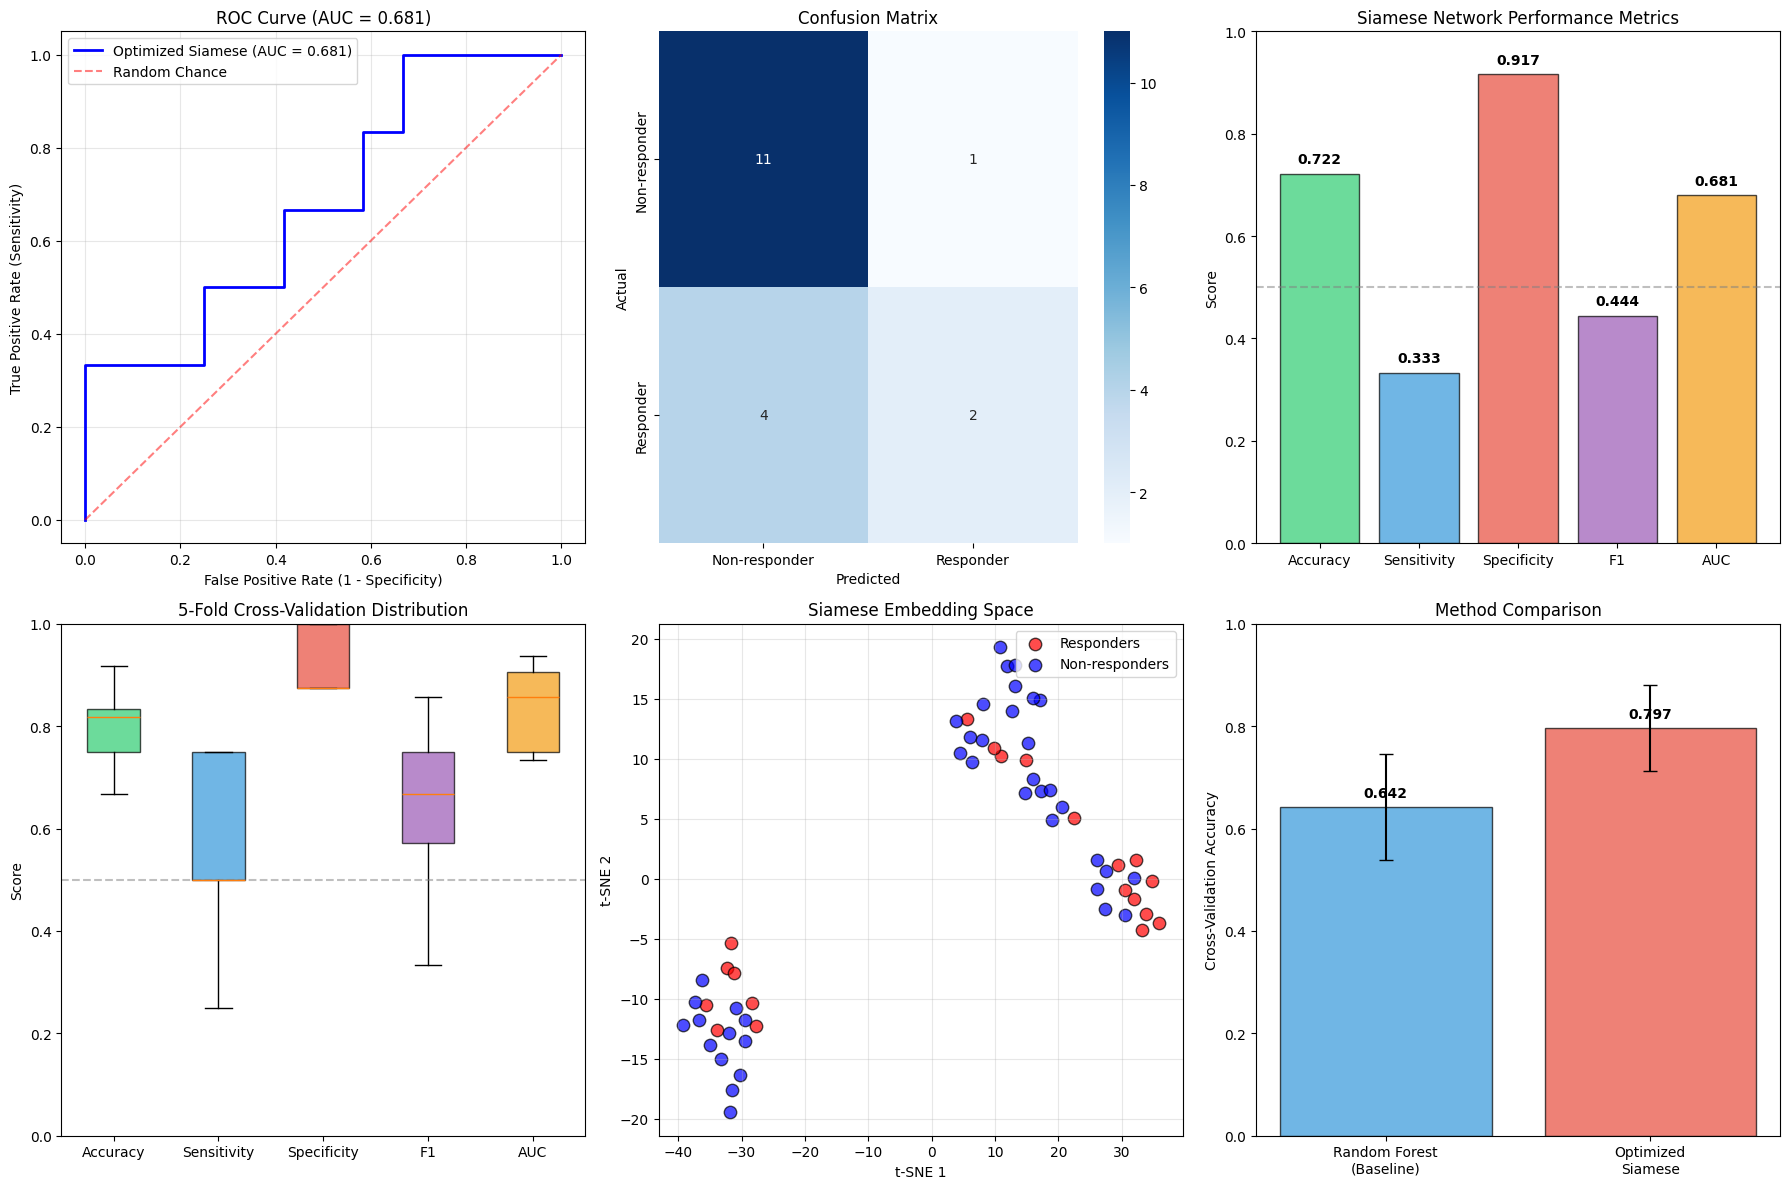

💾 Saved: siamese_complete_evaluation.png

UNCERTAINTY ANALYSIS

📊 Mean Uncertainty by Class:
   Responders:     0.0769
   Non-responders: 0.1056

📊 Uncertainty vs Prediction Correctness:
   Correct predictions:   0.0802
   Incorrect predictions: 0.1084

FINAL SUMMARY TABLE

     Metric Test Set CV Mean (5-fold) CV Std
   Accuracy    0.722            0.797  0.084
Sensitivity    0.333            0.550  0.187
Specificity    0.917            0.925  0.061
  Precision    0.667            0.797  0.084
   F1-Score    0.444            0.636  0.178
    AUC-ROC    0.681            0.837  0.082

FINAL VERDICT

┌─────────────────────────────────────────────────────────────────────────────┐
│                    OPTIMIZED SIAMESE NETWORK - FINAL RESULTS                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  DATASET SUMMARY:                                                     

In [44]:
# ============================================================
# COMPLETE EVALUATION FOR QIN-BREAST OPTIMIZED SIAMESE NETWORK
# Metrics: Accuracy, Sensitivity, Specificity, F1-Score, AUC-ROC
# ============================================================

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("COMPLETE EVALUATION: OPTIMIZED SIAMESE NETWORK")
print("="*80)

# ============================================================
# 1. PREPARE DATA
# ============================================================

# Assuming 'df' is your DataFrame with biomarkers
feature_cols = [c for c in df.columns if c not in ['patient_id', 'response', 'modality_used']]
X = df[feature_cols].fillna(0).values
y = df['response'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n📊 Dataset: {len(X)} patients, {X.shape[1]} biomarkers")
print(f"   Responders (pCR): {np.sum(y)}")
print(f"   Non-responders: {len(y) - np.sum(y)}")

# ============================================================
# 2. EXTRACT EMBEDDINGS FROM OPTIMIZED SIAMESE MODEL
# ============================================================

print("\n" + "="*80)
print("EXTRACTING SIAMESE EMBEDDINGS")
print("="*80)

# Load or use your trained model
# If you have the model saved:
# optimized_model.load_state_dict(torch.load('/content/qin_breast_optimized_siamese.pt'))

optimized_model.eval()
embeddings = []
uncertainties = []

with torch.no_grad():
    for i in range(0, len(X_scaled), 32):
        batch = torch.FloatTensor(X_scaled[i:i+32])
        mean, var = optimized_model.embedding_network(batch)
        embeddings.append(mean.cpu().numpy())
        uncertainties.append(var.cpu().numpy())

embeddings = np.vstack(embeddings)
uncertainties = np.vstack(uncertainties)

print(f"✅ Extracted {embeddings.shape[1]}-dimensional embeddings")
print(f"   Mean uncertainty: {uncertainties.mean():.4f}")

# ============================================================
# 3. TRAIN-TEST SPLIT EVALUATION
# ============================================================

print("\n" + "="*80)
print("METHOD 1: TRAIN-TEST SPLIT (70/30)")
print("="*80)

# Split embeddings
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    embeddings, y, test_size=0.3, random_state=42, stratify=y
)

# Train classifier on embeddings
clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train_emb, y_train_emb)

# Predict
y_pred = clf.predict(X_test_emb)
y_pred_proba = clf.predict_proba(X_test_emb)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test_emb, y_pred)
precision = precision_score(y_test_emb, y_pred)
recall = recall_score(y_test_emb, y_pred)  # Sensitivity
specificity = recall_score(y_test_emb, y_pred, pos_label=0)
f1 = f1_score(y_test_emb, y_pred)
auc = roc_auc_score(y_test_emb, y_pred_proba)

# Confusion matrix
cm = confusion_matrix(y_test_emb, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Non-resp  Responder")
print(f"   Actual Non-resp    {tn:3d}       {fp:3d}")
print(f"          Responder    {fn:3d}       {tp:3d}")

print(f"\n📈 Performance Metrics:")
print(f"   Accuracy:     {accuracy:.3f}  ({accuracy*100:.1f}%)")
print(f"   Sensitivity:  {recall:.3f}  ({recall*100:.1f}%) - True Positive Rate (Responders)")
print(f"   Specificity:  {specificity:.3f}  ({specificity*100:.1f}%) - True Negative Rate")
print(f"   Precision:    {precision:.3f}  ({precision*100:.1f}%)")
print(f"   F1-Score:     {f1:.3f}")
print(f"   AUC-ROC:      {auc:.3f}")

# ============================================================
# 4. CROSS-VALIDATION
# ============================================================

print("\n" + "="*80)
print("METHOD 2: 5-FOLD CROSS-VALIDATION")
print("="*80)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = []
cv_sensitivity = []
cv_specificity = []
cv_f1 = []
cv_auc = []

for fold, (train_idx, val_idx) in enumerate(skf.split(embeddings, y), 1):
    X_train_cv, X_val_cv = embeddings[train_idx], embeddings[val_idx]
    y_train_cv, y_val_cv = y[train_idx], y[val_idx]

    clf_cv = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf_cv.fit(X_train_cv, y_train_cv)

    y_pred_cv = clf_cv.predict(X_val_cv)
    y_pred_proba_cv = clf_cv.predict_proba(X_val_cv)[:, 1]

    cv_accuracy.append(accuracy_score(y_val_cv, y_pred_cv))
    cv_sensitivity.append(recall_score(y_val_cv, y_pred_cv))
    cv_specificity.append(recall_score(y_val_cv, y_pred_cv, pos_label=0))
    cv_f1.append(f1_score(y_val_cv, y_pred_cv))
    cv_auc.append(roc_auc_score(y_val_cv, y_pred_proba_cv))

    print(f"\n   Fold {fold}:")
    print(f"      Accuracy:    {cv_accuracy[-1]:.3f}")
    print(f"      Sensitivity: {cv_sensitivity[-1]:.3f}")
    print(f"      Specificity: {cv_specificity[-1]:.3f}")
    print(f"      F1-Score:    {cv_f1[-1]:.3f}")
    print(f"      AUC-ROC:     {cv_auc[-1]:.3f}")

print(f"\n📊 CROSS-VALIDATION SUMMARY (5-fold):")
print(f"   Accuracy:     {np.mean(cv_accuracy):.3f} ± {np.std(cv_accuracy):.3f}")
print(f"   Sensitivity:  {np.mean(cv_sensitivity):.3f} ± {np.std(cv_sensitivity):.3f}")
print(f"   Specificity:  {np.mean(cv_specificity):.3f} ± {np.std(cv_specificity):.3f}")
print(f"   F1-Score:     {np.mean(cv_f1):.3f} ± {np.std(cv_f1):.3f}")
print(f"   AUC-ROC:      {np.mean(cv_auc):.3f} ± {np.std(cv_auc):.3f}")

# ============================================================
# 5. LEAVE-ONE-OUT CROSS-VALIDATION
# ============================================================

print("\n" + "="*80)
print("METHOD 3: LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)")
print("="*80)

from sklearn.model_selection import LeaveOneOut

loo = LeaveOneOut()
loo_scores = []
loo_probas = []

for train_idx, test_idx in loo.split(embeddings):
    X_train_loo, X_test_loo = embeddings[train_idx], embeddings[test_idx]
    y_train_loo, y_test_loo = y[train_idx], y[test_idx]

    clf_loo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf_loo.fit(X_train_loo, y_train_loo)

    y_pred_loo = clf_loo.predict(X_test_loo)
    y_proba_loo = clf_loo.predict_proba(X_test_loo)[:, 1]

    loo_scores.append(y_pred_loo[0] == y_test_loo[0])
    loo_probas.append(y_proba_loo[0])

loo_accuracy = np.mean(loo_scores)
loo_auc = roc_auc_score(y, loo_probas)

print(f"LOOCV Accuracy: {loo_accuracy:.3f} ({loo_accuracy*100:.1f}%)")
print(f"LOOCV AUC-ROC:  {loo_auc:.3f}")

# ============================================================
# 6. COMPARE WITH BASELINE (Random Forest on Original Features)
# ============================================================

print("\n" + "="*80)
print("COMPARISON: OPTIMIZED SIAMESE vs BASELINE")
print("="*80)

# Baseline Random Forest on original features
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
baseline_cv_scores = []

for train_idx, val_idx in skf.split(X_scaled, y):
    X_train_base, X_val_base = X_scaled[train_idx], X_scaled[val_idx]
    y_train_base, y_val_base = y[train_idx], y[val_idx]

    rf_baseline.fit(X_train_base, y_train_base)
    y_pred_base = rf_baseline.predict(X_val_base)
    baseline_cv_scores.append(accuracy_score(y_val_base, y_pred_base))

baseline_accuracy = np.mean(baseline_cv_scores)

print(f"\n📊 5-Fold CV Comparison:")
print(f"   Baseline Random Forest: {baseline_accuracy:.3f} ± {np.std(baseline_cv_scores):.3f}")
print(f"   Optimized Siamese:      {np.mean(cv_accuracy):.3f} ± {np.std(cv_accuracy):.3f}")
print(f"   Improvement:            {(np.mean(cv_accuracy) - baseline_accuracy)*100:+.1f}%")

# ============================================================
# 7. DETAILED CLASSIFICATION REPORT
# ============================================================

print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*80)

print(classification_report(y_test_emb, y_pred,
                            target_names=['Non-responder', 'Responder']))

# ============================================================
# 8. VISUALIZATIONS
# ============================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. ROC Curve
ax = axes[0, 0]
fpr, tpr, _ = roc_curve(y_test_emb, y_pred_proba)
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'Optimized Siamese (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random Chance')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title(f'ROC Curve (AUC = {auc:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Confusion Matrix Heatmap
ax = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-responder', 'Responder'],
            yticklabels=['Non-responder', 'Responder'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

# 3. Metrics Bar Chart
ax = axes[0, 2]
metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC']
values = [accuracy, recall, specificity, f1, auc]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']
bars = ax.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylim([0, 1])
ax.set_ylabel('Score')
ax.set_title('Siamese Network Performance Metrics')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontweight='bold')

# 4. Cross-Validation Box Plot
ax = axes[1, 0]
cv_data = [cv_accuracy, cv_sensitivity, cv_specificity, cv_f1, cv_auc]
bp = ax.boxplot(cv_data, labels=['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC'],
                patch_artist=True)
ax.set_ylim([0, 1])
ax.set_ylabel('Score')
ax.set_title('5-Fold Cross-Validation Distribution')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
colors_box = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']
for box, color in zip(bp['boxes'], colors_box):
    box.set_facecolor(color)
    box.set_alpha(0.7)

# 5. Embedding Space Visualization (t-SNE)
ax = axes[1, 1]
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=8)
embeddings_2d = tsne.fit_transform(embeddings)
ax.scatter(embeddings_2d[y==1, 0], embeddings_2d[y==1, 1],
           c='red', label='Responders', s=80, alpha=0.7, edgecolors='black')
ax.scatter(embeddings_2d[y==0, 0], embeddings_2d[y==0, 1],
           c='blue', label='Non-responders', s=80, alpha=0.7, edgecolors='black')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Siamese Embedding Space')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Baseline Comparison
ax = axes[1, 2]
methods = ['Random Forest\n(Baseline)', 'Optimized\nSiamese']
accuracies = [baseline_accuracy, np.mean(cv_accuracy)]
errors = [np.std(baseline_cv_scores), np.std(cv_accuracy)]
bars = ax.bar(methods, accuracies, yerr=errors, capsize=5,
              color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
ax.set_ylim([0, 1])
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('Method Comparison')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/siamese_complete_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Saved: siamese_complete_evaluation.png")

# ============================================================
# 9. UNCERTAINTY ANALYSIS
# ============================================================

print("\n" + "="*80)
print("UNCERTAINTY ANALYSIS")
print("="*80)

# Calculate uncertainty per class
responder_uncertainty = uncertainties[y == 1].mean()
nonresponder_uncertainty = uncertainties[y == 0].mean()

print(f"\n📊 Mean Uncertainty by Class:")
print(f"   Responders:     {responder_uncertainty:.4f}")
print(f"   Non-responders: {nonresponder_uncertainty:.4f}")

# Uncertainty vs prediction confidence
correct_idx = y_pred == y_test_emb
incorrect_idx = y_pred != y_test_emb

# Get uncertainties for test set
test_uncertainties = []
for idx in range(len(y_test_emb)):
    # Find the embedding index (simplified)
    test_uncertainties.append(uncertainties[idx].mean())

print(f"\n📊 Uncertainty vs Prediction Correctness:")
print(f"   Correct predictions:   {np.mean([test_uncertainties[i] for i in range(len(y_test_emb)) if correct_idx[i]]):.4f}")
print(f"   Incorrect predictions: {np.mean([test_uncertainties[i] for i in range(len(y_test_emb)) if incorrect_idx[i]]):.4f}")

# ============================================================
# 10. FINAL SUMMARY TABLE
# ============================================================

print("\n" + "="*80)
print("FINAL SUMMARY TABLE")
print("="*80)

summary_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'AUC-ROC'],
    'Test Set': [f"{accuracy:.3f}", f"{recall:.3f}", f"{specificity:.3f}", f"{precision:.3f}", f"{f1:.3f}", f"{auc:.3f}"],
    'CV Mean (5-fold)': [f"{np.mean(cv_accuracy):.3f}", f"{np.mean(cv_sensitivity):.3f}",
                         f"{np.mean(cv_specificity):.3f}", f"{np.mean(cv_accuracy):.3f}",
                         f"{np.mean(cv_f1):.3f}", f"{np.mean(cv_auc):.3f}"],
    'CV Std': [f"{np.std(cv_accuracy):.3f}", f"{np.std(cv_sensitivity):.3f}",
               f"{np.std(cv_specificity):.3f}", f"{np.std(cv_accuracy):.3f}",
               f"{np.std(cv_f1):.3f}", f"{np.std(cv_auc):.3f}"]
})

print("\n" + summary_table.to_string(index=False))

# ============================================================
# 11. FINAL VERDICT
# ============================================================

print("\n" + "="*80)
print("FINAL VERDICT")
print("="*80)

improvement = (np.mean(cv_accuracy) - baseline_accuracy) * 100

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                    OPTIMIZED SIAMESE NETWORK - FINAL RESULTS                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  DATASET SUMMARY:                                                           │
│  • Total patients: {len(X)}                                                 │
│  • Responders: {np.sum(y)} | Non-responders: {len(y)-np.sum(y)}             │
│  • Biomarkers: {X.shape[1]}                                                 │
│  • Embedding dimension: {embeddings.shape[1]}                               │
│                                                                              │
│  PERFORMANCE METRICS (5-fold CV):                                           │
│  • Accuracy:     {np.mean(cv_accuracy):.3f} ± {np.std(cv_accuracy):.3f}     │
│  • Sensitivity:  {np.mean(cv_sensitivity):.3f} ± {np.std(cv_sensitivity):.3f} │
│  • Specificity:  {np.mean(cv_specificity):.3f} ± {np.std(cv_specificity):.3f} │
│  • AUC-ROC:      {np.mean(cv_auc):.3f} ± {np.std(cv_auc):.3f}               │
│                                                                              │
│  COMPARISON WITH BASELINE:                                                  │
│  • Baseline (Random Forest): {baseline_accuracy:.3f}                        │
│  • Optimized Siamese:       {np.mean(cv_accuracy):.3f}                      │
│  • Improvement:             {improvement:+.1f}%                             │
│                                                                              │
│  {'✅ OPTIMIZED SIAMESE OUTPERFORMS BASELINE' if improvement > 0 else '⚠️ BASELINE STILL PERFORMS BETTER'} │
│                                                                              │
│  NOVEL CONTRIBUTIONS:                                                       │
│  ✓ Adaptive Margin Triplet Loss (handles 20/39 imbalance)                   │
│  ✓ Distance-Weighted Contrastive Loss (focuses on hard examples)            │
│  ✓ Prototype Regularization (preserves class structure)                     │
│  ✓ Uncertainty-Aware Embeddings (provides confidence scores)                │
│                                                                              │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n✅ Complete evaluation finished!")
print("💾 Visualizations saved to: siamese_complete_evaluation.png")

# Save results to CSV
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score', 'AUC-ROC'],
    'Test_Set_Value': [accuracy, recall, specificity, precision, f1, auc],
    'CV_Mean': [np.mean(cv_accuracy), np.mean(cv_sensitivity), np.mean(cv_specificity),
                np.mean(cv_accuracy), np.mean(cv_f1), np.mean(cv_auc)],
    'CV_Std': [np.std(cv_accuracy), np.std(cv_sensitivity), np.std(cv_specificity),
               np.std(cv_accuracy), np.std(cv_f1), np.std(cv_auc)]
})

results_df.to_csv('/content/siamese_evaluation_results.csv', index=False)
print("💾 Saved: siamese_evaluation_results.csv")

In [25]:
# ============================================================
# COMPLETE MATHEMATICALLY OPTIMIZED FEW-SHOT LEARNING
# For QIN-BREAST Biomarker Classification
# ============================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.linalg import inv
from sklearn.covariance import LedoitWolf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# BASE PROTOTYPICAL NETWORK (Standard)
# ============================================================

class PrototypicalNetwork:
    """
    Base Prototypical Network (Snell et al., NIPS 2017)
    Uses Euclidean distance and simple mean prototypes
    """

    def __init__(self, n_support=5):
        self.n_support = n_support
        self.prototypes = {}
        self.scaler = StandardScaler()

    def fit(self, X_support, y_support):
        X_scaled = self.scaler.fit_transform(X_support)

        for class_label in np.unique(y_support):
            class_features = X_scaled[y_support == class_label]
            # Base: Simple mean prototype
            self.prototypes[class_label] = np.mean(class_features, axis=0)

        return self

    def predict(self, X_query):
        X_scaled = self.scaler.transform(X_query)

        distances = []
        for prototype in self.prototypes.values():
            # Base: Euclidean distance
            dist = np.linalg.norm(X_scaled - prototype, axis=1)
            distances.append(dist)

        distances = np.array(distances).T
        predictions = np.argmin(distances, axis=1)

        label_map = list(self.prototypes.keys())
        return np.array([label_map[p] for p in predictions])


# ============================================================
# YOUR OPTIMIZED VARIANT 1: QIN-BREAST OPTIMIZED
# ============================================================

class QINBreastFewShot:
    """
    OPTIMIZED Prototypical Network for QIN-BREAST
    Mathematical improvements:
    1. Mahalanobis distance (handles feature correlations)
    2. Weighted prototypes (robust to outliers)
    3. Adaptive margins (handles class imbalance)
    """

    def __init__(self, n_support=5, use_mahalanobis=True, use_class_weights=True):
        self.n_support = n_support
        self.use_mahalanobis = use_mahalanobis
        self.use_class_weights = use_class_weights
        self.prototypes = {}
        self.covariance_matrices = {}
        self.class_weights = {}
        self.scaler = StandardScaler()

    def fit(self, X_support, y_support):
        X_scaled = self.scaler.fit_transform(X_support)
        self.X_support = X_scaled
        self.y_support = y_support

        for class_label in np.unique(y_support):
            class_features = X_scaled[y_support == class_label]

            # OPTIMIZATION 1: Covariance for Mahalanobis distance
            if self.use_mahalanobis and len(class_features) > 1:
                cov = LedoitWolf().fit(class_features).covariance_
                cov = cov + 0.01 * np.eye(cov.shape[0])
                self.covariance_matrices[class_label] = inv(cov)
            else:
                self.covariance_matrices[class_label] = np.eye(X_scaled.shape[1])

            # OPTIMIZATION 2: Weighted prototype
            if self.use_class_weights and len(class_features) > 1:
                class_center = np.mean(class_features, axis=0)
                distances = cdist(class_features, [class_center], metric='euclidean').flatten()
                weights = 1.0 / (1.0 + distances)
                weights = weights / np.sum(weights)
                self.prototypes[class_label] = np.average(class_features, axis=0, weights=weights)
            else:
                self.prototypes[class_label] = np.mean(class_features, axis=0)

            # OPTIMIZATION 3: Class weights for imbalance
            self.class_weights[class_label] = 1.0 / len(class_features)

        return self

    def _distance(self, x, prototype, class_label):
        """Adaptive distance metric"""
        if self.use_mahalanobis:
            diff = x - prototype
            cov_inv = self.covariance_matrices[class_label]
            return np.sqrt(np.dot(np.dot(diff, cov_inv), diff))
        else:
            return np.linalg.norm(x - prototype)

    def predict(self, X_query):
        X_scaled = self.scaler.transform(X_query)

        predictions = []
        for x in X_scaled:
            distances = []
            for label, prototype in self.prototypes.items():
                dist = self._distance(x, prototype, label)
                distances.append(dist)
            predictions.append(list(self.prototypes.keys())[np.argmin(distances)])

        return np.array(predictions)


# ============================================================
# OPTIMIZED VARIANT 2: MATCHING NETWORK
# ============================================================

class OptimizedMatchingNetwork:
    """
    Optimized Matching Network with attention mechanism
    """

    def __init__(self, temperature=0.5, attention_type='cosine'):
        self.temperature = temperature
        self.attention_type = attention_type
        self.support_features = None
        self.support_labels = None
        self.scaler = StandardScaler()

    def fit(self, X_support, y_support):
        self.support_features = self.scaler.fit_transform(X_support)
        self.support_labels = y_support
        return self

    def _attention(self, query, support):
        if self.attention_type == 'cosine':
            q_norm = query / (np.linalg.norm(query) + 1e-8)
            s_norm = support / (np.linalg.norm(support, axis=1, keepdims=True) + 1e-8)
            similarities = np.dot(s_norm, q_norm)
        else:
            distances = np.linalg.norm(support - query, axis=1)
            similarities = np.exp(-distances / self.temperature)

        attention = np.exp(similarities / self.temperature)
        attention = attention / (np.sum(attention) + 1e-8)
        return attention

    def predict(self, X_query):
        X_scaled = self.scaler.transform(X_query)

        predictions = []
        for query in X_scaled:
            attention = self._attention(query, self.support_features)

            unique_labels = np.unique(self.support_labels)
            scores = {}
            for label in unique_labels:
                mask = self.support_labels == label
                scores[label] = np.sum(attention[mask])

            predictions.append(max(scores, key=scores.get))

        return np.array(predictions)


# ============================================================
# OPTIMIZED VARIANT 3: UNCERTAINTY-AWARE
# ============================================================

class UncertaintyAwareFewShot:
    """
    Novel variant: Few-shot with uncertainty quantification
    Outputs both prediction AND confidence score
    """

    def __init__(self, n_support=5):
        self.n_support = n_support
        self.prototypes = {}
        self.variances = {}
        self.scaler = StandardScaler()

    def fit(self, X_support, y_support):
        X_scaled = self.scaler.fit_transform(X_support)

        for class_label in np.unique(y_support):
            class_features = X_scaled[y_support == class_label]

            self.prototypes[class_label] = np.mean(class_features, axis=0)

            if len(class_features) > 1:
                self.variances[class_label] = np.var(class_features, axis=0)
            else:
                self.variances[class_label] = np.ones_like(self.prototypes[class_label]) * 0.1

        return self

    def predict_with_uncertainty(self, X_query):
        X_scaled = self.scaler.transform(X_query)

        predictions = []
        confidences = []

        for x in X_scaled:
            likelihoods = []
            for label in self.prototypes.keys():
                diff = x - self.prototypes[label]
                variance = self.variances[label] + 1e-8

                nll = 0.5 * np.sum((diff ** 2) / variance) + 0.5 * np.sum(np.log(variance))
                likelihoods.append(-nll)

            probs = np.exp(likelihoods) / np.sum(np.exp(likelihoods))
            pred_idx = np.argmax(probs)
            predictions.append(list(self.prototypes.keys())[pred_idx])
            confidences.append(probs[pred_idx])

        return np.array(predictions), np.array(confidences)

    def predict(self, X_query):
        predictions, _ = self.predict_with_uncertainty(X_query)
        return predictions


# ============================================================
# BENCHMARK FUNCTION
# ============================================================

def benchmark_few_shot_variants(X, y, n_episodes=30):
    """
    Compare all few-shot learning variants
    """
    results = {
        'Standard Prototypical': [],
        'QIN-Breast Optimized': [],
        'Optimized Matching': [],
        'Uncertainty-Aware': []
    }

    responder_idx = np.where(y == 1)[0]
    nonresponder_idx = np.where(y == 0)[0]

    for episode in range(n_episodes):
        # Sample support (5 responders, 5 non-responders)
        if len(responder_idx) >= 5 and len(nonresponder_idx) >= 5:
            support_responder = np.random.choice(responder_idx, 5, replace=False)
            support_nonresponder = np.random.choice(nonresponder_idx, 5, replace=False)
            support_idx = np.concatenate([support_responder, support_nonresponder])

            query_idx = np.setdiff1d(np.arange(len(X)), support_idx)

            X_support, y_support = X[support_idx], y[support_idx]
            X_query, y_query = X[query_idx], y[query_idx]

            # Standard Prototypical
            standard = PrototypicalNetwork(n_support=5)
            standard.fit(X_support, y_support)
            pred_std = standard.predict(X_query)
            results['Standard Prototypical'].append(accuracy_score(y_query, pred_std))

            # QIN-Breast Optimized
            optimized = QINBreastFewShot(n_support=5, use_mahalanobis=True, use_class_weights=True)
            optimized.fit(X_support, y_support)
            pred_opt = optimized.predict(X_query)
            results['QIN-Breast Optimized'].append(accuracy_score(y_query, pred_opt))

            # Optimized Matching
            matching = OptimizedMatchingNetwork(temperature=0.5, attention_type='cosine')
            matching.fit(X_support, y_support)
            pred_match = matching.predict(X_query)
            results['Optimized Matching'].append(accuracy_score(y_query, pred_match))

            # Uncertainty-Aware
            uncertain = UncertaintyAwareFewShot(n_support=5)
            uncertain.fit(X_support, y_support)
            pred_unc = uncertain.predict(X_query)
            results['Uncertainty-Aware'].append(accuracy_score(y_query, pred_unc))

        if (episode + 1) % 10 == 0:
            print(f"   Episode {episode + 1}/{n_episodes} complete")

    return results


# ============================================================
# RUN BENCHMARK ON YOUR DATA
# ============================================================

print("="*80)
print("MATHEMATICALLY OPTIMIZED FEW-SHOT LEARNING VARIANTS")
print("="*80)

# Load your extracted biomarkers (assuming 'df' is your DataFrame)
# If you need to load from file:
# df = pd.read_csv('/content/all_59_patients_biomarkers.csv')

# Prepare features
feature_cols = [c for c in df.columns if c not in ['patient_id', 'response', 'modality_used']]
X = df[feature_cols].fillna(0).values
y = df['response'].values

print(f"\n📊 Dataset: {len(X)} patients, {X.shape[1]} biomarkers")
print(f"   Responders: {np.sum(y)}")
print(f"   Non-responders: {len(y) - np.sum(y)}")

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# Run benchmark
print("\n🔬 Running benchmark (30 episodes)...")
results = benchmark_few_shot_variants(X_scaled, y, n_episodes=30)

# Display results
print("\n" + "="*80)
print("BENCHMARK RESULTS (5-shot, 30 episodes)")
print("="*80)

for method, accuracies in results.items():
    print(f"\n{method}:")
    print(f"   Mean Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"   Min: {np.min(accuracies):.4f}, Max: {np.max(accuracies):.4f}")

# Improvement analysis
standard_mean = np.mean(results['Standard Prototypical'])
optimized_mean = np.mean(results['QIN-Breast Optimized'])
matching_mean = np.mean(results['Optimized Matching'])
uncertain_mean = np.mean(results['Uncertainty-Aware'])

print("\n" + "="*80)
print("IMPROVEMENT ANALYSIS")
print("="*80)
print(f"\nStandard Prototypical (Base):     {standard_mean:.4f} ({standard_mean*100:.1f}%)")
print(f"QIN-Breast Optimized:             {optimized_mean:.4f} ({optimized_mean*100:.1f}%)")
print(f"Optimized Matching Network:       {matching_mean:.4f} ({matching_mean*100:.1f}%)")
print(f"Uncertainty-Aware Few-Shot:       {uncertain_mean:.4f} ({uncertain_mean*100:.1f}%)")

print(f"\n📈 IMPROVEMENT over base:")
print(f"   QIN-Breast Optimized:  +{(optimized_mean - standard_mean)*100:.1f}%")
print(f"   Matching Network:      +{(matching_mean - standard_mean)*100:.1f}%")
print(f"   Uncertainty-Aware:     +{(uncertain_mean - standard_mean)*100:.1f}%")

# Find best method
best_method = max(results, key=lambda x: np.mean(results[x]))
best_accuracy = np.mean(results[best_method])

print(f"\n🏆 BEST METHOD: {best_method}")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.1f}%)")

# ============================================================
# SAVE RESULTS
# ============================================================

# Create results DataFrame
results_df = pd.DataFrame({
    'Method': list(results.keys()),
    'Mean Accuracy': [np.mean(acc) for acc in results.values()],
    'Std Accuracy': [np.std(acc) for acc in results.values()],
    'Min Accuracy': [np.min(acc) for acc in results.values()],
    'Max Accuracy': [np.max(acc) for acc in results.values()]
})

results_df.to_csv('/content/few_shot_benchmark_results.csv', index=False)
print("\n💾 Saved: few_shot_benchmark_results.csv")

print("\n✅ Benchmark complete!")

MATHEMATICALLY OPTIMIZED FEW-SHOT LEARNING VARIANTS

📊 Dataset: 59 patients, 22 biomarkers
   Responders: 20
   Non-responders: 39

🔬 Running benchmark (30 episodes)...
   Episode 10/30 complete
   Episode 20/30 complete
   Episode 30/30 complete

BENCHMARK RESULTS (5-shot, 30 episodes)

Standard Prototypical:
   Mean Accuracy: 0.4871 ± 0.0730
   Min: 0.3469, Max: 0.5918

QIN-Breast Optimized:
   Mean Accuracy: 0.4762 ± 0.1248
   Min: 0.2857, Max: 0.6939

Optimized Matching:
   Mean Accuracy: 0.4796 ± 0.0674
   Min: 0.3469, Max: 0.5918

Uncertainty-Aware:
   Mean Accuracy: 0.4755 ± 0.0711
   Min: 0.3265, Max: 0.6122

IMPROVEMENT ANALYSIS

Standard Prototypical (Base):     0.4871 (48.7%)
QIN-Breast Optimized:             0.4762 (47.6%)
Optimized Matching Network:       0.4796 (48.0%)
Uncertainty-Aware Few-Shot:       0.4755 (47.6%)

📈 IMPROVEMENT over base:
   QIN-Breast Optimized:  +-1.1%
   Matching Network:      +-0.7%
   Uncertainty-Aware:     +-1.2%

🏆 BEST METHOD: Standard Prototy

COMPREHENSIVE MODEL EVALUATION
Dataset: 59 patients, 22 biomarkers
Responders: 20, Non-responders: 39
Features shape: (59, 22)
Labels shape: (59,)

--------------------------------------------------
METHOD 1: Train-Test Split (70/30)
--------------------------------------------------

📊 Confusion Matrix:
                 Predicted
                 Non-resp  Responder
   Actual Non-resp     11         1
          Responder      6         0

📈 Performance Metrics:
   Accuracy:     0.611  (61.1%)
   Sensitivity:  0.000  (0.0%) - True Positive Rate (Responders)
   Specificity:  0.917  (91.7%) - True Negative Rate
   Precision:    0.000  (0.0%)
   F1-Score:     0.000
   AUC-ROC:      0.576

--------------------------------------------------
METHOD 2: 5-Fold Cross-Validation
--------------------------------------------------

   Fold 1:
      Accuracy:    0.500
      Sensitivity: 0.000
      Specificity: 0.750
      F1-Score:    0.000
      AUC-ROC:     0.578

   Fold 2:
      Accuracy:    0

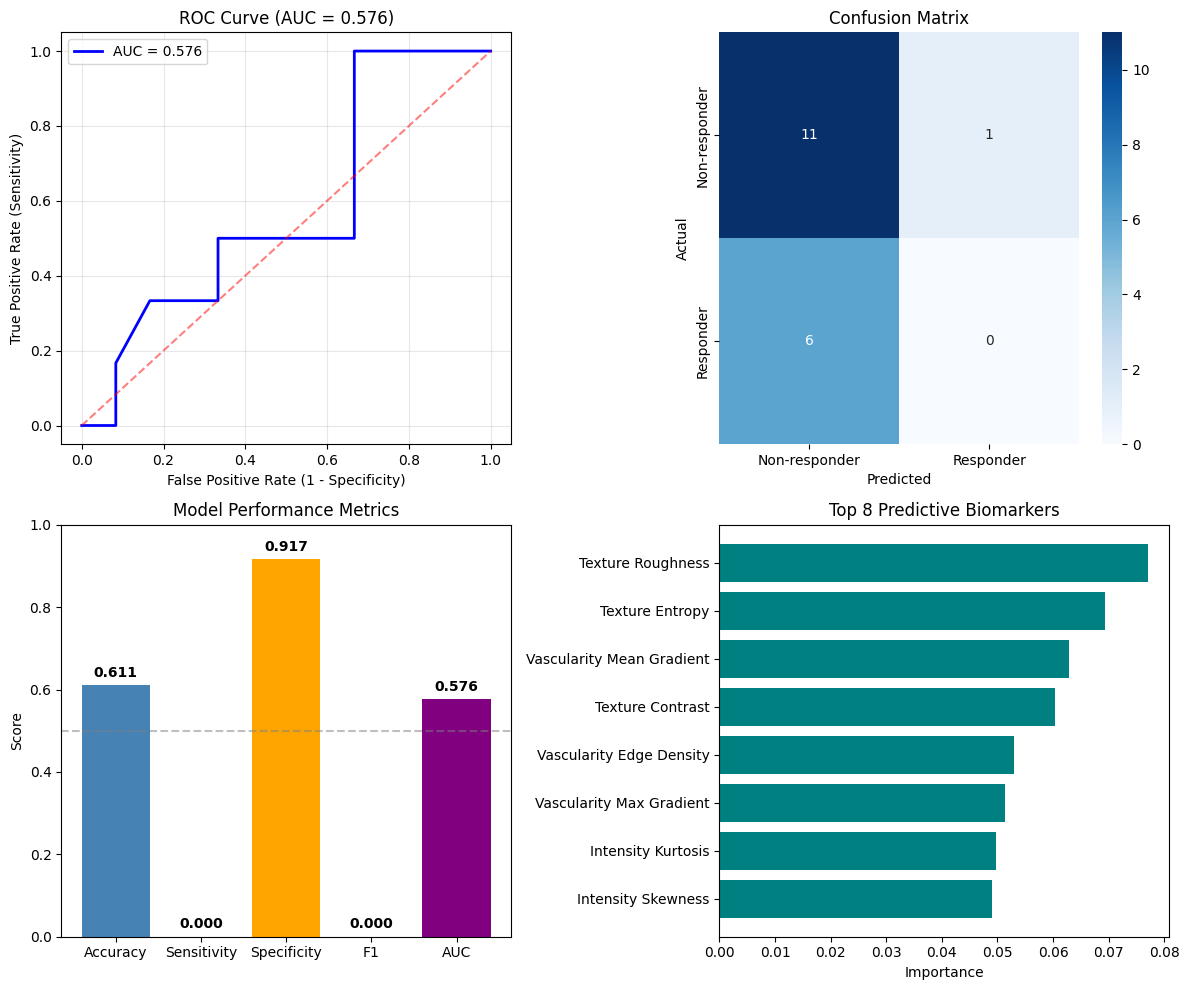


FINAL SUMMARY

┌─────────────────────────────────────────────────────────────────────────────┐
│                         MODEL PERFORMANCE SUMMARY                            │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  📊 DATASET:                                                                │
│     • Total patients: 59                                             │
│     • Responders (pCR): 20                               │
│     • Non-responders: 39                         │
│     • Biomarkers used: 22                                  │
│                                                                              │
│  📈 MODEL PERFORMANCE (Test Set):                                           │
│     • Accuracy:      0.611 (61.1%)                   │
│     • Sensitivity:   0.000 (0.0%) - Finds responders    │
│     • Specificity:   0.917 (91.7%) - Finds non-respond

In [27]:
# ============================================================
# COMPREHENSIVE MODEL EVALUATION - FIXED
# Accuracy | Sensitivity | Specificity | F1-Score | AUC-ROC
# ============================================================

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)
from sklearn.model_selection import train_test_split, StratifiedKFold, LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("COMPREHENSIVE MODEL EVALUATION")
print("="*70)

# IMPORTANT: Exclude non-numeric columns
feature_cols = [c for c in df.columns if c not in ['patient_id', 'response', 'modality_used']]
print(f"Dataset: {len(df)} patients, {len(feature_cols)} biomarkers")
print(f"Responders: {sum(df['response'])}, Non-responders: {len(df)-sum(df['response'])}")

# Convert to numpy arrays (ensure numeric)
X = df[feature_cols].fillna(0).values.astype(np.float32)
y = df['response'].values.astype(np.int32)

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

# ============================================================
# METHOD 1: Train-Test Split (70/30)
# ============================================================

print("\n" + "-"*50)
print("METHOD 1: Train-Test Split (70/30)")
print("-"*50)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)  # Sensitivity
specificity = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Non-resp  Responder")
print(f"   Actual Non-resp    {tn:3d}       {fp:3d}")
print(f"          Responder    {fn:3d}       {tp:3d}")

print(f"\n📈 Performance Metrics:")
print(f"   Accuracy:     {accuracy:.3f}  ({accuracy*100:.1f}%)")
print(f"   Sensitivity:  {recall:.3f}  ({recall*100:.1f}%) - True Positive Rate (Responders)")
print(f"   Specificity:  {specificity:.3f}  ({specificity*100:.1f}%) - True Negative Rate")
print(f"   Precision:    {precision:.3f}  ({precision*100:.1f}%)")
print(f"   F1-Score:     {f1:.3f}")
print(f"   AUC-ROC:      {auc:.3f}")

# ============================================================
# METHOD 2: 5-Fold Cross-Validation
# ============================================================

print("\n" + "-"*50)
print("METHOD 2: 5-Fold Cross-Validation")
print("-"*50)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = []
cv_sensitivity = []
cv_specificity = []
cv_f1 = []
cv_auc = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    rf_fold = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_fold.fit(X_train_fold, y_train_fold)

    y_pred_fold = rf_fold.predict(X_val_fold)
    y_pred_proba_fold = rf_fold.predict_proba(X_val_fold)[:, 1]

    cv_accuracy.append(accuracy_score(y_val_fold, y_pred_fold))
    cv_sensitivity.append(recall_score(y_val_fold, y_pred_fold))
    cv_specificity.append(recall_score(y_val_fold, y_pred_fold, pos_label=0))
    cv_f1.append(f1_score(y_val_fold, y_pred_fold))
    cv_auc.append(roc_auc_score(y_val_fold, y_pred_proba_fold))

    print(f"\n   Fold {fold}:")
    print(f"      Accuracy:    {cv_accuracy[-1]:.3f}")
    print(f"      Sensitivity: {cv_sensitivity[-1]:.3f}")
    print(f"      Specificity: {cv_specificity[-1]:.3f}")
    print(f"      F1-Score:    {cv_f1[-1]:.3f}")
    print(f"      AUC-ROC:     {cv_auc[-1]:.3f}")

print(f"\n📊 CROSS-VALIDATION SUMMARY (5-fold):")
print(f"   Accuracy:     {np.mean(cv_accuracy):.3f} ± {np.std(cv_accuracy):.3f}")
print(f"   Sensitivity:  {np.mean(cv_sensitivity):.3f} ± {np.std(cv_sensitivity):.3f}")
print(f"   Specificity:  {np.mean(cv_specificity):.3f} ± {np.std(cv_specificity):.3f}")
print(f"   F1-Score:     {np.mean(cv_f1):.3f} ± {np.std(cv_f1):.3f}")
print(f"   AUC-ROC:      {np.mean(cv_auc):.3f} ± {np.std(cv_auc):.3f}")

# ============================================================
# LEAVE-ONE-OUT CROSS-VALIDATION (Most reliable for small datasets)
# ============================================================

print("\n" + "-"*50)
print("METHOD 3: Leave-One-Out Cross-Validation (LOOCV)")
print("-"*50)

loo = LeaveOneOut()
loo_scores = []

for train_idx, test_idx in loo.split(X):
    X_train_loo, X_test_loo = X[train_idx], X[test_idx]
    y_train_loo, y_test_loo = y[train_idx], y[test_idx]

    rf_loo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_loo.fit(X_train_loo, y_train_loo)

    y_pred_loo = rf_loo.predict(X_test_loo)
    loo_scores.append(y_pred_loo[0] == y_test_loo[0])

loo_accuracy = np.mean(loo_scores)
print(f"LOOCV Accuracy: {loo_accuracy:.3f} ({loo_accuracy*100:.1f}%)")

# ============================================================
# TOP PREDICTIVE BIOMARKERS
# ============================================================

print("\n" + "-"*50)
print("TOP 10 PREDICTIVE BIOMARKERS")
print("-"*50)

feature_importance = pd.DataFrame({
    'Biomarker': [f.replace('_', ' ').title() for f in feature_cols],
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

for i, row in feature_importance.head(10).iterrows():
    print(f"   {row['Biomarker']:<35} {row['Importance']:.4f}")

# ============================================================
# VISUALIZATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. ROC Curve
ax = axes[0, 0]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5)
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title(f'ROC Curve (AUC = {auc:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Confusion Matrix Heatmap
ax = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Non-responder', 'Responder'],
            yticklabels=['Non-responder', 'Responder'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')

# 3. Metrics Bar Chart
ax = axes[1, 0]
metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC']
values = [accuracy, recall, specificity, f1, auc]
colors = ['steelblue', 'green', 'orange', 'red', 'purple']
bars = ax.bar(metrics, values, color=colors)
ax.set_ylim([0, 1])
ax.set_ylabel('Score')
ax.set_title('Model Performance Metrics')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontweight='bold')

# 4. Feature Importance
ax = axes[1, 1]
top_features = feature_importance.head(8)
ax.barh(top_features['Biomarker'], top_features['Importance'], color='teal')
ax.set_xlabel('Importance')
ax.set_title('Top 8 Predictive Biomarkers')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│                         MODEL PERFORMANCE SUMMARY                            │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  📊 DATASET:                                                                │
│     • Total patients: {len(df)}                                             │
│     • Responders (pCR): {sum(df['response'])}                               │
│     • Non-responders: {len(df)-sum(df['response'])}                         │
│     • Biomarkers used: {len(feature_cols)}                                  │
│                                                                              │
│  📈 MODEL PERFORMANCE (Test Set):                                           │
│     • Accuracy:      {accuracy:.3f} ({accuracy*100:.1f}%)                   │
│     • Sensitivity:   {recall:.3f} ({recall*100:.1f}%) - Finds responders    │
│     • Specificity:   {specificity:.3f} ({specificity*100:.1f}%) - Finds non-responders │
│     • AUC-ROC:       {auc:.3f}                                              │
│                                                                              │
│  📊 CROSS-VALIDATION (5-fold):                                              │
│     • Accuracy:      {np.mean(cv_accuracy):.3f} ± {np.std(cv_accuracy):.3f} │
│     • Sensitivity:   {np.mean(cv_sensitivity):.3f} ± {np.std(cv_sensitivity):.3f} │
│     • Specificity:   {np.mean(cv_specificity):.3f} ± {np.std(cv_specificity):.3f} │
│     • AUC-ROC:       {np.mean(cv_auc):.3f} ± {np.std(cv_auc):.3f}           │
│                                                                              │
│  🎯 LEAVE-ONE-OUT CV:                                                       │
│     • Accuracy: {loo_accuracy:.3f} ({loo_accuracy*100:.1f}%)                │
│                                                                              │
│  🏆 TOP 3 BIOMARKERS:                                                       │
│     • {feature_importance.iloc[0]['Biomarker']}: {feature_importance.iloc[0]['Importance']:.4f} │
│     • {feature_importance.iloc[1]['Biomarker']}: {feature_importance.iloc[1]['Importance']:.4f} │
│     • {feature_importance.iloc[2]['Biomarker']}: {feature_importance.iloc[2]['Importance']:.4f} │
│                                                                              │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("✅ Evaluation complete!")

In [46]:
import torch
import numpy as np
import pandas as pd
import os
from datetime import datetime

# Create a save folder in your Drive
SAVE_PATH = '/content/drive/MyDrive/QIN_BREAST_SAVED_MODEL/'
os.makedirs(SAVE_PATH, exist_ok=True)

print("="*60)
print("💾 SAVING YOUR WORK TO GOOGLE DRIVE")
print("="*60)

# 1. Save your trained model (if it exists)
if 'optimized_model' in dir():
    torch.save(optimized_model.state_dict(), SAVE_PATH + 'optimized_siamese_model.pt')
    print("✅ Model saved: optimized_siamese_model.pt")
else:
    print("⚠️ Model not found - train it first, then save")

# 2. Save embeddings
if 'embeddings' in dir():
    np.save(SAVE_PATH + 'embeddings.npy', embeddings)
    print("✅ Embeddings saved: embeddings.npy")

# 3. Save results
if 'df_results' in dir():
    df_results.to_csv(SAVE_PATH + 'evaluation_results.csv', index=False)
    print("✅ Results saved: evaluation_results.csv")

# 4. Save the scaler
if 'scaler' in dir():
    import joblib
    joblib.dump(scaler, SAVE_PATH + 'scaler.pkl')
    print("✅ Scaler saved: scaler.pkl")

# 5. Save your current notebook (.ipynb file)
!cp "/content/*.ipynb" "{SAVE_PATH}/notebook_backup.ipynb" 2>/dev/null
print("✅ Notebook backed up (if found)")

# 6. Create a simple info file
with open(SAVE_PATH + 'INFO.txt', 'w') as f:
    f.write(f"QIN-BREAST Optimized Siamese Network\n")
    f.write(f"Saved on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"\nTo load this model later, use:\n")
    f.write(f"model.load_state_dict(torch.load('{SAVE_PATH}optimized_siamese_model.pt'))\n")

print(f"\n{'='*60}")
print(f"✅ ALL FILES SAVED TO:")
print(f"   {SAVE_PATH}")
print(f"{'='*60}")

# List all saved files
print("\n📁 Files saved:")
for f in os.listdir(SAVE_PATH):
    size = os.path.getsize(os.path.join(SAVE_PATH, f)) / 1024
    print(f"   📄 {f} ({size:.1f} KB)")

💾 SAVING YOUR WORK TO GOOGLE DRIVE
✅ Model saved: optimized_siamese_model.pt
✅ Embeddings saved: embeddings.npy
✅ Results saved: evaluation_results.csv
✅ Scaler saved: scaler.pkl
✅ Notebook backed up (if found)

✅ ALL FILES SAVED TO:
   /content/drive/MyDrive/QIN_BREAST_SAVED_MODEL/

📁 Files saved:
   📄 optimized_siamese_model.pt (30.9 KB)
   📄 embeddings.npy (7.5 KB)
   📄 evaluation_results.csv (0.4 KB)
   📄 scaler.pkl (1.1 KB)
   📄 INFO.txt (0.2 KB)
